<a href="https://colab.research.google.com/github/SamuelDare-programmer/CreditRisk/blob/main/ml/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
userdata.get('KAGGLE_API_TOKEN')

'KGAT_21c4114d14a47dabf703563bad04ca8c'

In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('home-credit-default-risk')

print("Path to competition files:", path)

100%|██████████| 688M/688M [00:26<00:00, 27.6MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/home-credit-default-risk


#Load Dataset

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
application_df = pd.read_csv(path + '/application_train.csv')

#Initial EDA

In [5]:
application_df.shape

(307511, 122)

In [ ]:
application_df.columns.to_list()

In [23]:
application_df.isnull().sum().sort_values(ascending=False).head(10)

,0
COMMONAREA_AVG,214865
COMMONAREA_MODE,214865
COMMONAREA_MEDI,214865
NONLIVINGAPARTMENTS_MEDI,213514
NONLIVINGAPARTMENTS_MODE,213514
NONLIVINGAPARTMENTS_AVG,213514
FONDKAPREMONT_MODE,210295
LIVINGAPARTMENTS_AVG,210199
LIVINGAPARTMENTS_MEDI,210199
LIVINGAPARTMENTS_MODE,210199


### 1. Target Distribution
Let's start by looking at the balance of the target classes to see if the dataset is imbalanced.

/tmp/ipykernel_8492/1044222459.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET', data=application_df, palette='viridis')


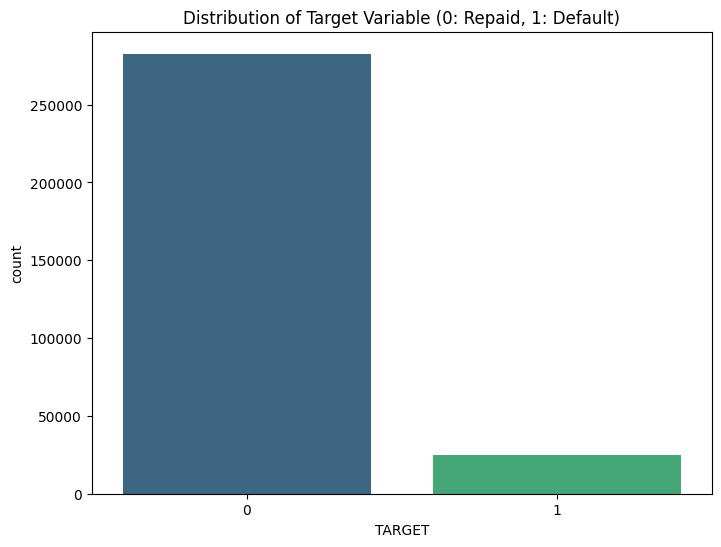

Percentage of defaults: 8.07%


In [12]:
plt.figure(figsize=(8, 6))
sns.countplot(x='TARGET', data=application_df, palette='viridis')
plt.title('Distribution of Target Variable (0: Repaid, 1: Default)')
plt.show()

print(f"Percentage of defaults: {100 * application_df['TARGET'].sum() / len(application_df):.2f}%")

### 2. Missing Values Analysis
Visualizing the percentage of missing values per column to identify columns that might need dropping or imputation.

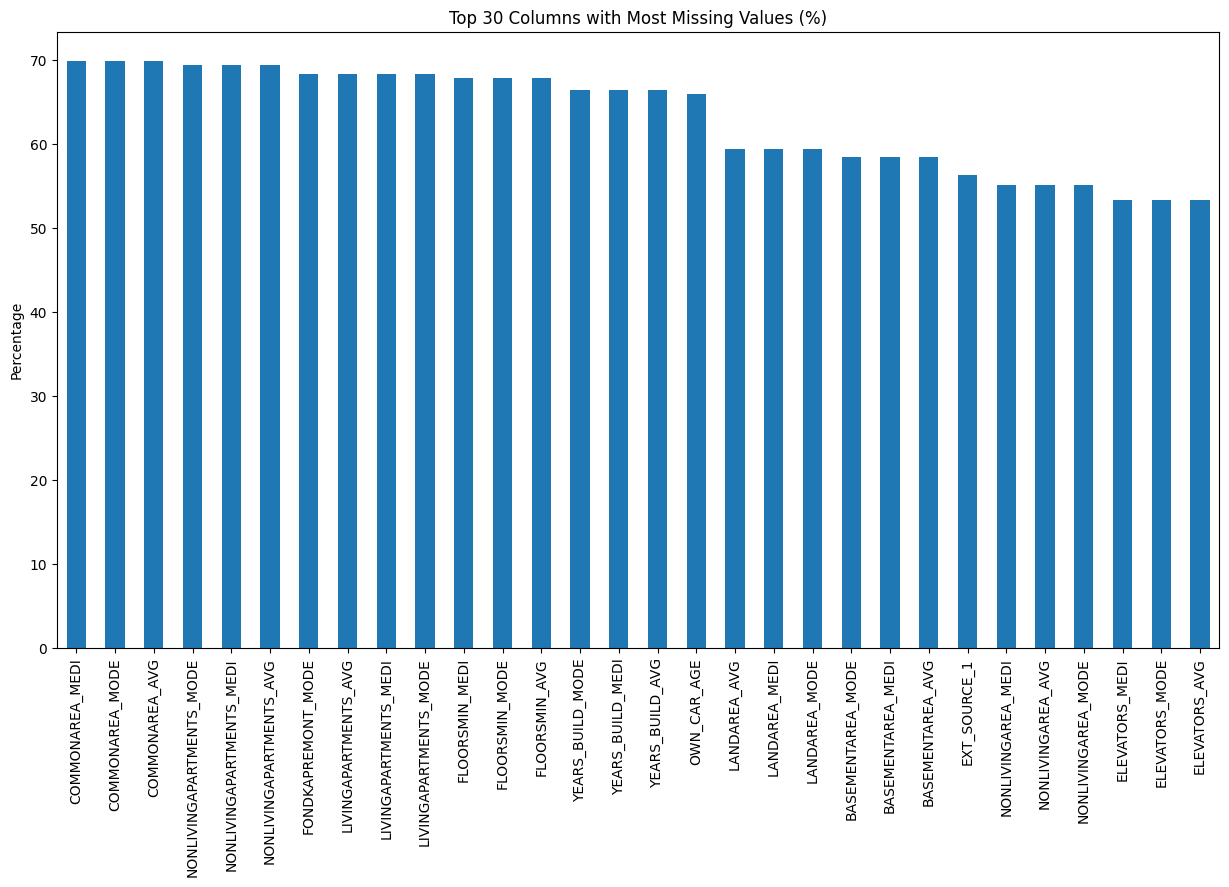

In [13]:
null_vals = application_df.isnull().sum() / len(application_df) * 100
null_vals = null_vals[null_vals > 0].sort_values(ascending=False)

plt.figure(figsize=(15, 8))
null_vals[:30].plot(kind='bar')
plt.title('Top 30 Columns with Most Missing Values (%)')
plt.ylabel('Percentage')
plt.show()

### 3. Distribution of Age and Income
Let's examine the age (converted from `DAYS_BIRTH`) and the total income distribution.

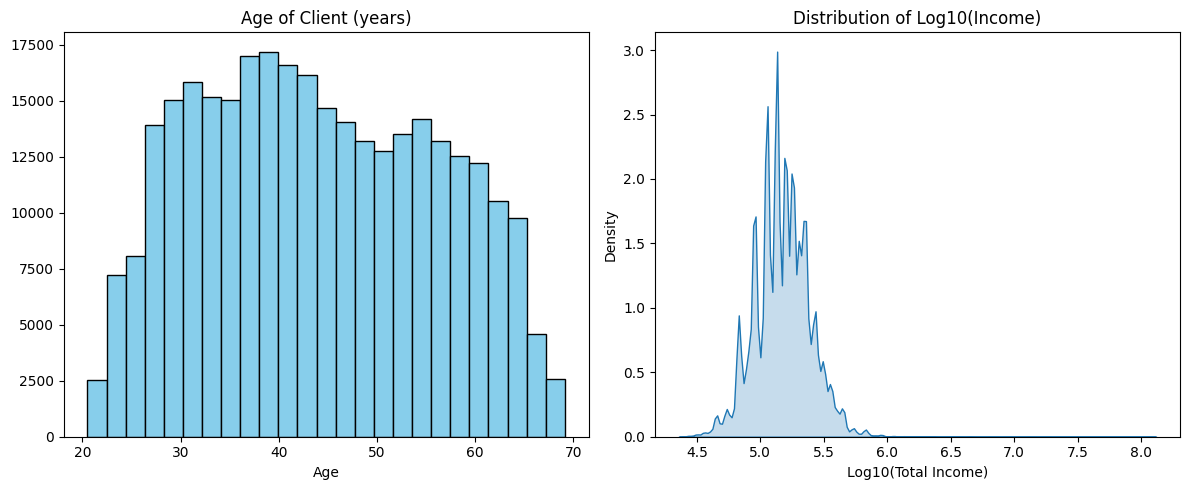

In [14]:
plt.figure(figsize=(12, 5))

# Age distribution
plt.subplot(1, 2, 1)
plt.hist(application_df['DAYS_BIRTH'] / -365, edgecolor='k', bins=25, color='skyblue')
plt.title('Age of Client (years)')
plt.xlabel('Age')

# Income distribution (log scale for better view due to outliers)
plt.subplot(1, 2, 2)
sns.kdeplot(np.log10(application_df['AMT_INCOME_TOTAL']), fill=True)
plt.title('Distribution of Log10(Income)')
plt.xlabel('Log10(Total Income)')

plt.tight_layout()
plt.show()

### 4. Categorical Variables vs Target
Visualizing how contract types and gender relate to the target.

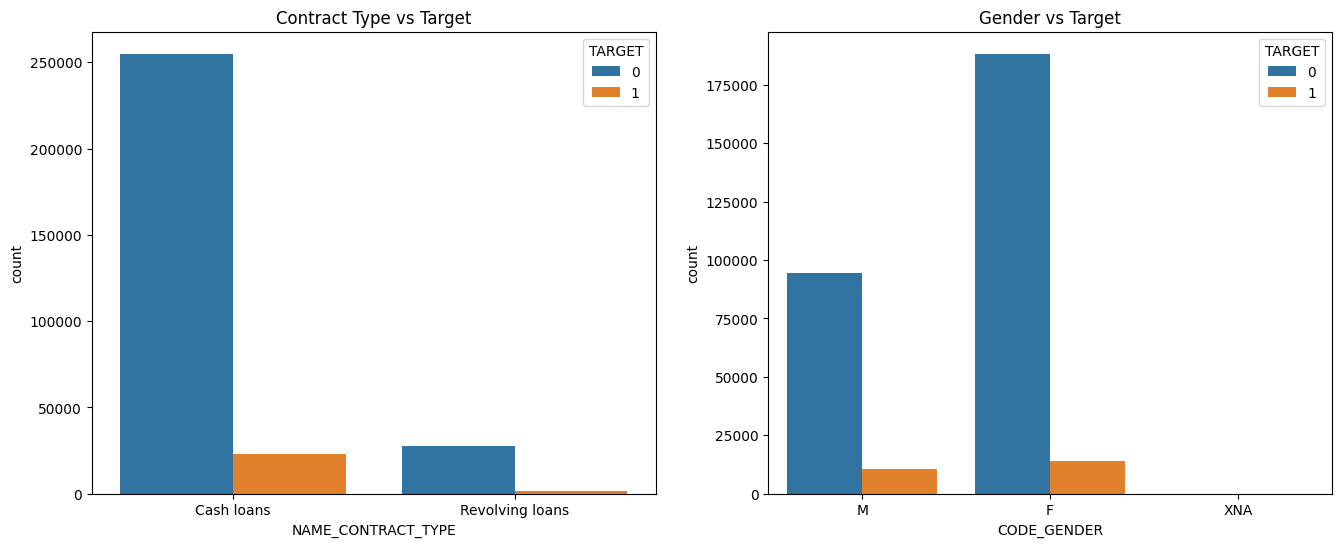

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(x='NAME_CONTRACT_TYPE', hue='TARGET', data=application_df, ax=ax[0])
ax[0].set_title('Contract Type vs Target')

sns.countplot(x='CODE_GENDER', hue='TARGET', data=application_df, ax=ax[1])
ax[1].set_title('Gender vs Target')

plt.show()

### 5. Correlation Analysis
We will look for the features most strongly correlated with the `TARGET` (repayment difficulty).

In [24]:
# Calculate correlations
# Correlation measures the linear relationship between two variables on a scale of -1 to 1.
correlations = application_df.select_dtypes(include=[np.number]).corr()['TARGET'].sort_values()

print('Most Positive Correlations:\n', correlations.tail(11))
print('\nMost Negative Correlations:\n', correlations.head(10))

# Interpretation:
# Negative Correlation: As the feature increases, the risk of default (TARGET=1) decreases.
# Positive Correlation: As the feature increases, the risk of default (TARGET=1) increases.
# Note: DAYS_BIRTH is negative, so a positive correlation means younger people (closer to 0) are higher risk.

Most Positive Correlations:
 DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

Most Negative Correlations:
 EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
Name: TARGET, dtype: float64


Now, let's visualize the correlation of the top 15 features with the Target.

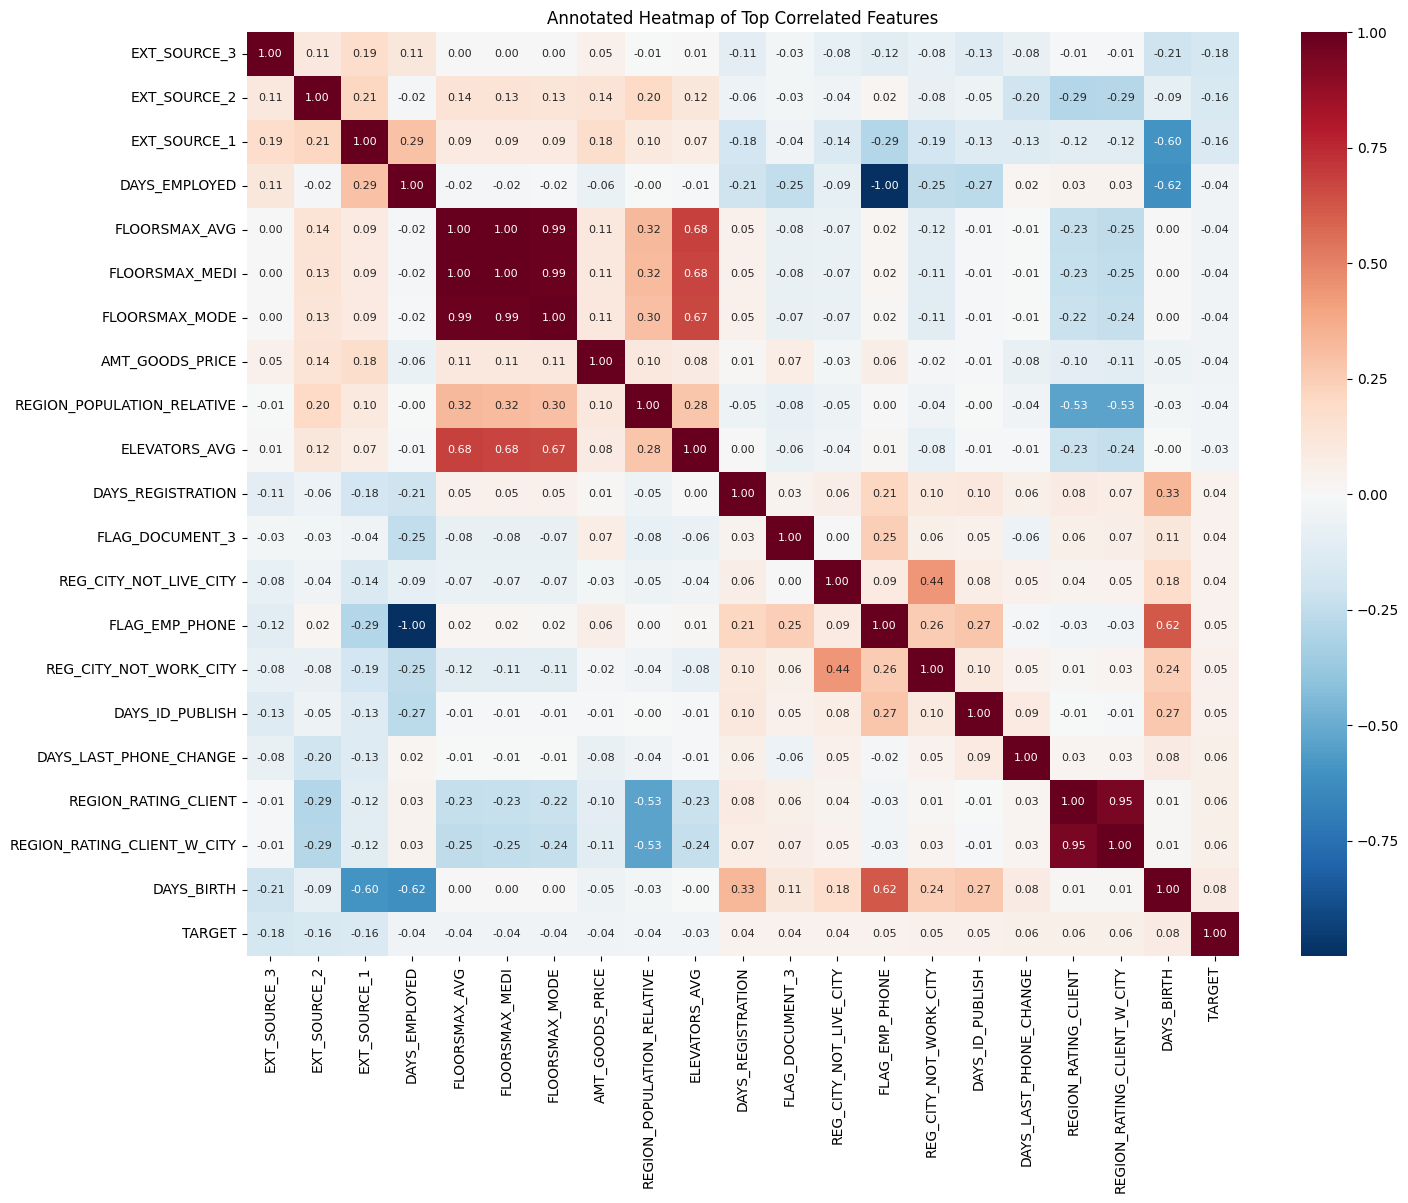

The heatmap now includes numeric correlation coefficients (annotations) for easier interpretation.


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select top correlated features
top_feature_names = correlations.head(10).index.tolist() + correlations.tail(11).index.tolist()
feature_corr_matrix = application_df[top_feature_names].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(feature_corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, annot_kws={'size': 8})
plt.title('Annotated Heatmap of Top Correlated Features')
plt.show()

print("The heatmap now includes numeric correlation coefficients (annotations) for easier interpretation.")